In [2]:
library(tidyverse)

In [4]:
df = read.csv("gsea_prerank_results/Adipocyte_DCM_prerank_GSEA.csv")

In [17]:
cell_types <- c("Adipocyte", "Cardiomyocyte", "Endothelial",
        "Fibroblast", "LEC", "Lymphoid", "Myeloid", "Neuronal", "Pericyte")
diseases <- c("DCM", "HCM", "ICM")

In [18]:
all_gsea <- data.frame()

for (cell_type in cell_types) {
  for (disease in diseases) {
    
    # read gseapy res
    file_path <- paste0("gsea_prerank_results/", cell_type, "_", disease, "_prerank_GSEA.csv")
    df <- read.csv(file_path)

    # filter to significant
    filt_df <- df[df$FDR.q.val < 0.05, ]
    filt_df$cell_type <- cell_type
    filt_df$disease <- disease
    
    all_gsea <- rbind(all_gsea, filt_df)
  }
}

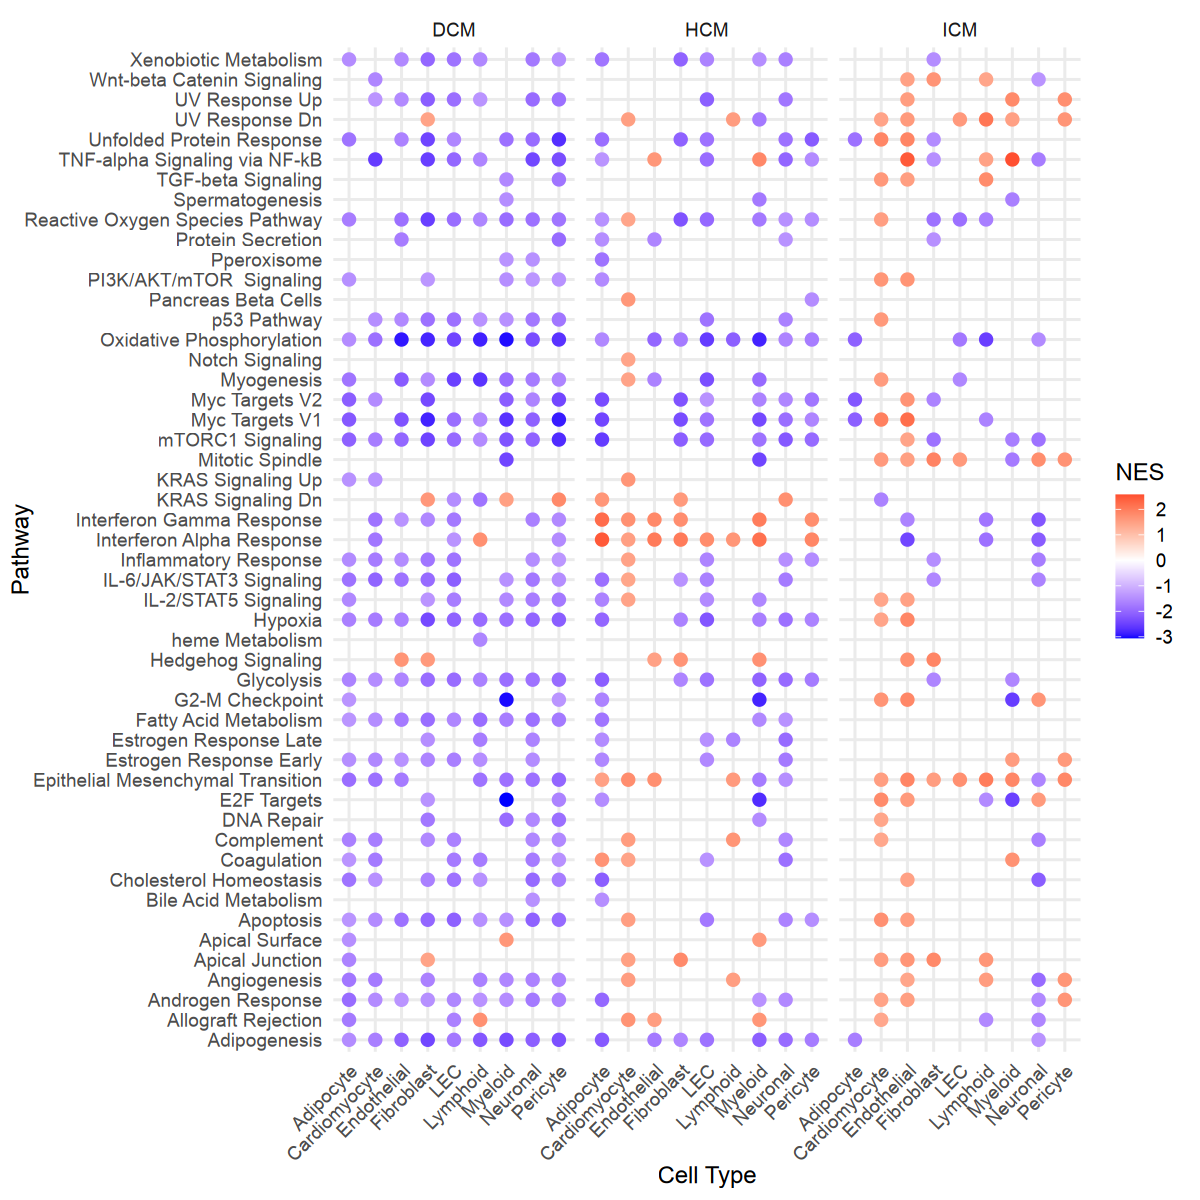

In [33]:
options(repr.plot.width = 10, repr.plot.height = 10)

p1 <- ggplot(all_gsea, aes(x = cell_type, y = Term, color = NES)) +
  geom_point(size = 3) +
  facet_wrap(~ disease) +
  scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  labs(x = "Cell Type", y = "Pathway", color = "NES") +
  theme_minimal(base_size = 14) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p1

ggsave(p1, filename = "02E_gsea_results.pdf", width = 10, height = 10)